# Training an MLP on Time Series Data
This notebook demonstrates how to train a Multi-Layer Perceptron (MLP) network using the 3W dataset for Multiclass Classification with Time Series data using the ThreeWToolkit.

### Imports
We start by importing the required libraries and classes from the Toolkit. 

In [ ]:
from ThreeWToolkit.trainer import TorchTrainerConfig
from ThreeWToolkit.models import MLPConfig
from ThreeWToolkit.dataset import ParquetDatasetConfig, TransformConfig
from ThreeWToolkit.preprocessing import (
    SequentialPreprocessingAdapterConfig,
    FillLabelsConfig,
    CleanSignalsConfig,
    ImputeMissingConfig,
    NormalizeConfig,
    RemapClassConfig,
)
from ThreeWToolkit.feature_extraction import (
    SequentialFeatureAdapterConfig,
    WindowingConfig,
    ConcatFeatureAdapterConfig,
    StatisticalConfig,
)
from ThreeWToolkit.assessment import (
    ModelAssessmentConfig,
    AssessmentVisualizationConfig,
)
from ThreeWToolkit.utils import TrainTestSplitter
import matplotlib.pyplot as plt

RANDOM_SEED = 2026

### Loading and preparing the dataset

The next step is to create a ParqueDataset instance to interact with the *3W dataset*, for that we have to define a path location where we want to save the Dataset to (or where it is already located).

In [26]:
# Modify this path to the folder where your dataset is downloaded
dataset_path = "../../dataset"

ds_train = ParquetDatasetConfig(
    path=dataset_path, event_type=["simulated"], target_class=[1, 2, 3, 4, 5]
).build()

ds_train, ds_val = TrainTestSplitter(
    size_training=0.6, size_test=0.4, shuffle=True, random_state=RANDOM_SEED
).split_data(ds_train)

ds_val, ds_test = TrainTestSplitter(
    size_training=0.5, size_test=0.5, shuffle=True, random_state=RANDOM_SEED
).split_data(ds_val)

print(f"Train dataset size: {len(ds_train)}")
print(f"Validation dataset size: {len(ds_val)}")
print(f"Test dataset size: {len(ds_test)}")

2026-04-21 13:05:43,989 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-21 13:05:43,990 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-21 13:05:43,990 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


Train dataset size: 385
Validation dataset size: 129
Test dataset size: 129


Here we need to create a relevant pipeline for pre-processing and transforming the Dataset. 

- The methods *CleanSignals*, *ImputeMissing*, *RemapClass* and *FillLabels* are very important in order to fix the occurrence of *NaN* values. 

- For training with the models available in the 3WToolkit, we also need to apply *Windowing*. 

- For demonstration purposes, we create a **Sequential** feature processing, that will first apply *Windowing*, and proceeds to a *Concatenation* of more features (in this case, we will only be using Statistical)

In [ ]:
window_size = 128
dataset_processor = TransformConfig(
    pre_processing=SequentialPreprocessingAdapterConfig(
        steps=[
            CleanSignalsConfig(),
            ImputeMissingConfig(),
            NormalizeConfig(),
            FillLabelsConfig(),
            RemapClassConfig(),
        ]
    ),
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            WindowingConfig(window_size=window_size),
            ConcatFeatureAdapterConfig(steps=[StatisticalConfig()]),
        ]
    ),
).build()

dataset_processor.fit(ds_train)
ds_train_transformed = dataset_processor.transform(ds_train)
ds_val_transformed = dataset_processor.transform(ds_val)
ds_test_transformed = dataset_processor.transform(ds_test)

### Model Trainer Configurations

With the data ready, we are now able to define a **Trainer**, to use a simple *MLP* model we will create a *MLPConfig*, in order to train any Torch Model implemented from a *TorchModels*, the *TorchTrainerConfig* needs to be used.

- Very important to note that the *TorchTrainerConfig* class receives as a parameter the model configuration (MLPConfig), and we use this information to instantiate a **trainer** class.   

- We will be using *class_weights* in order to mitigate part of the class imbalance from the 3W Dataset. 

- Note that it was not needed to pass the *input_size* parameter to the *MLPConfig* as it uses lazy initialization. 

- We also used the *num_classes* property from the *Transform* method, which give us the exact number of classes after processing with the *RemapClass*.

In [ ]:
mlp_config = MLPConfig(
    hidden_sizes=(32, 16),
    output_size=dataset_processor.num_classes,
)

trainer = TorchTrainerConfig(
    seed=RANDOM_SEED,
    use_class_weights=True,
    class_weight_strategy="balanced",
    config_model=mlp_config,
    learning_rate=0.001,
    batch_size=64,
    epochs=35,
).build()

2026-04-21 13:06:13,607 | INFO | ThreeWToolkit.core.base_trainer | Initialized TorchTrainer with seed=2026
2026-04-21 13:06:13,608 | INFO | ThreeWToolkit.trainer.torch_trainer | TorchTrainer initialized | device=cuda | epochs=35 | batch_size=64


### Training the model

With the data and Trainer ready, we can call the *trainer.train()* method while passing the *train_dataset* and *val_dataset* argument. 

In [29]:
train_results = trainer.train(
    train_dataset=ds_train_transformed, val_dataset=ds_val_transformed
)

2026-04-21 13:06:13,624 | INFO | ThreeWToolkit.core.base_trainer | Starting training | train_size=385 | val_size=129
2026-04-21 13:06:13,677 | INFO | ThreeWToolkit.core.base_trainer | Dataset validation passed
2026-04-21 13:06:13,678 | INFO | ThreeWToolkit.core.base_trainer | Preparing training data...
2026-04-21 13:06:13,679 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=385)
2026-04-21 13:06:25,288 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=1922
2026-04-21 13:06:25,289 | INFO | ThreeWToolkit.core.base_trainer | Preparing validation data...
2026-04-21 13:06:25,290 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=129)
2026-04-21 13:06:29,224 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=602
2026-04-21 13:06:29,225 | INFO | ThreeWToolkit.core.base_trainer | Initializing training state...
2026-04-21 13:06:29,226 | INFO | ThreeWToolkit.trainer.torch_tr

Training:   0%|          | 0/35 [00:00<?, ?epoch/s]

2026-04-21 13:08:15,892 | INFO | ThreeWToolkit.core.base_trainer | Training completed successfully


In the object *train_results.history*, we have both lists of *val_loss* and *train_loss*, we can use them to create a plot that shows the changes over epochs. 

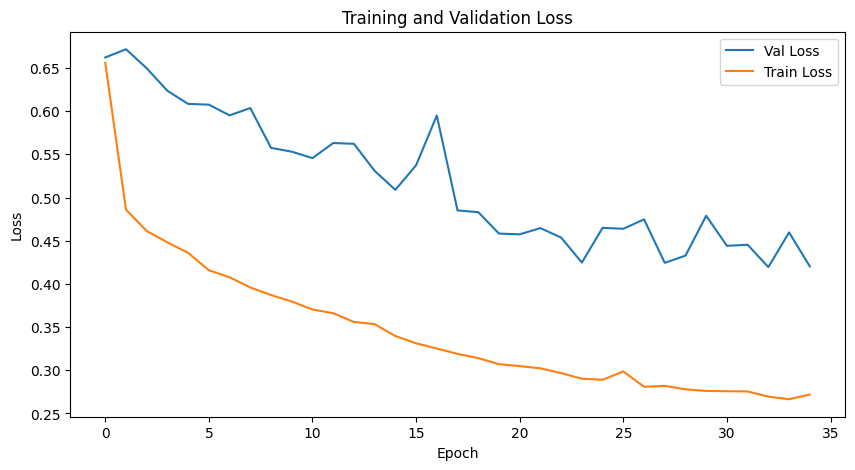

In [31]:
history = train_results.history
plt.figure(figsize=(10, 5))
plt.plot(history.val_loss, label="Val Loss")
plt.plot(history.train_loss, label="Train Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

In this plot we can observe that both *train_loss* and *val_loss* are decreasing.

### Test Assessment and Results
For gathering the results using the test set we will use the same *trainer* instance used for the training loop, but calling the method *trainer.predict*, with the **test_set** parameter. This will give us the *test_results* object.

With *test_results* we can use the **ModelAssessmentConfig**, and after building the instance, we can call *assessment.evaluate()* passing both *training_results* and *predictions*. 

In [ ]:
# Gather test_results using trainer's predict method
test_results = trainer.predict(ds_test_transformed)

assessment = ModelAssessmentConfig(
    metrics=["accuracy"],
).build()

# Evaluate model performance on test set using ModelAssessment
results = assessment.evaluate(training_results=train_results, predictions=test_results)

2026-04-21 13:08:17,821 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=129)
2026-04-21 13:08:22,121 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=643
2026-04-21 13:08:22,606 | INFO | ThreeWToolkit.assessment.model_assess | Results exported to /home/eduardo/3W/toolkit/output/exp_20260421_1308
2026-04-21 13:08:22,607 | INFO | ThreeWToolkit.assessment.model_assess | Model Assessment Summary
Model: MLP
Task Type: classification
Timestamp: 20260421_1308

Metrics:
  accuracy: 0.8545

Training History:
  Final train_loss: 0.2718
  Final val_loss: 0.4203


With the *test_results* we can instantiate a *plotter* using **AssessmentVisualization**, which provides the method *plot_confusion_matrix*, that accepts *y_true* and *y_pred*.

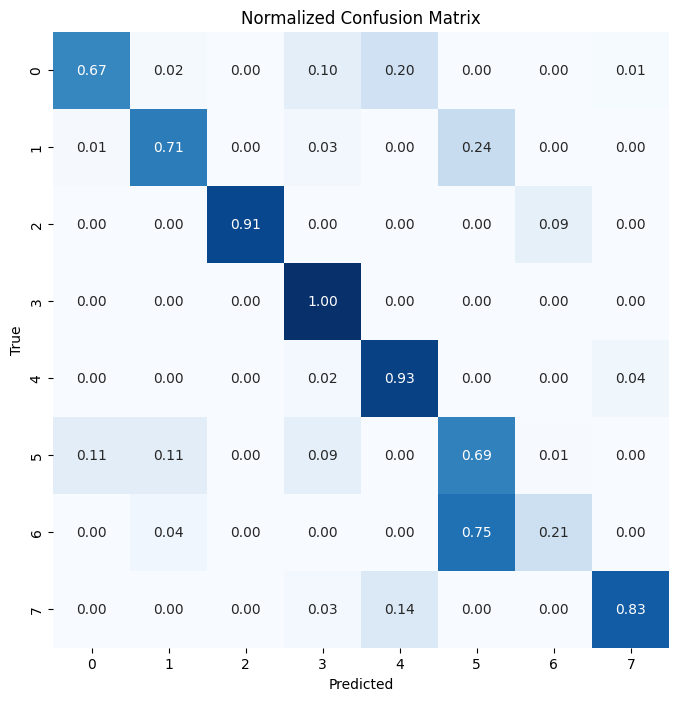

In [32]:
# Visualize training history
plotter = AssessmentVisualizationConfig().build()
fig = plotter.plot_confusion_matrix(
    y_true=test_results.y_true,
    y_pred=test_results.y_pred,
    normalize=True,
    title="Normalized Confusion Matrix",
)

__________